# Instructions

Hit "Run all" at the top of the notebook to load the latest dataset.

Then use the Table of contents to navigate to the desired section.

# Notebook Setup

In [ ]:
# @title
import os
!git clone https://github.com/vivyuen/Incognito.git

#print(os.getcwd())

fatal: destination path 'Incognito' already exists and is not an empty directory.


In [ ]:
# @title
# Setup
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import datetime as dt

## Install itables if not already installed and import it
try:
    import itables.interactive
except ImportError:
    %pip install itables
    import itables.interactive

# Enable interactive mode for all DataFrames
# itables.interactive.init_notebook_mode(all_interactive=False)

## Wrap text pandas table output
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Load & clean data
df = pd.read_csv('/content/Incognito/2026_Toronto_Womens_Tryout_Form_Responses.csv')

## Strip whitespace from column names
df.columns = df.columns.str.strip()

df = df.astype({'Timestamp': 'datetime64[ns]', 'Date of Birth': 'datetime64[ns]'})

## Add Age column
df['Age'] = (dt.datetime.now().year - df['Date of Birth'].dt.year)

## Clean Player Names
df['Name_clean'] = df['Name'].astype(str).str.strip()


# All Players

In [ ]:
# @title
print(f"Total Number of Form Responses: {df['Name_clean'].nunique()}")

Total Number of Form Responses: 69


### See All Form Responses

In [ ]:
# @title
display(df)

Loading ITables v2.7.3 from the internet... (need help?)


# Subsets of Players

## Cog Eligible

In [ ]:
# @title
# Cog inclusive
df_cog_inclusive = df[df['I am trying out for:'].str.contains("Incognito")]
df_cog_only = df[df['I am trying out for:'].str.contains("Incognito only")]

#df_cog.head(5)

print(f"Cog Eligible: {df_cog_inclusive['Name_clean'].nunique()}")
print(f"Cog Only: {df_cog_only['Name_clean'].nunique()}")


Cog Eligible: 39
Cog Only: 21


## Invited to 6ixers Tryout 1

In [ ]:
# @title
# Invited to 6ixers Tryout 1

df_6ixers_tryout1_invites = pd.read_csv(io.StringIO('''
Invites
Alyssa Mason
Jessie Tsang
Maia List
Tyama Lyall
Brittney Dos Santos
Sarah Lam
Sabrina Trung
Chloe Ringler
Hannah Dawson
Jessica Hou
Molly Lewis
Reve Chan
Jade
Melanie Tran
rachel cooc
Makayla Power
Jazmin Ulalan
Grażyna Chlebicka
Krystal Dos Santos
Jocelyn Li
belle ouyang
Mika Kurahashi
Joely Valencerina
Monica wang
Molly Wedge
Grace Wang
Huicong Lay
Eastelle
Aryanie Yang
Joyce Lei
Ava Pearson
'''))

In [ ]:
# @title
df_cog_tryout1 = df_cog_inclusive[~df_cog_inclusive['Name_clean'].isin(df_6ixers_tryout1_invites['Invites'])]
#df_cog_tryout1.head(5)

print(f"Cog Tryout 1: {df_cog_tryout1['Name_clean'].nunique()}")

Cog Tryout 1: 35


## Cog Tryout 1 Attendees

### Form Responses

In [ ]:
# @title
# Display the DataFrame interactively
display(df_cog_tryout1)

Loading ITables v2.7.3 from the internet... (need help?)


### See Specific Form Responses
Instructions: Select 'df_cog_tryout1' as your dataset to look at form responses for those attending Cog Tryout 1.

The dataset 'df' contains all form responses.

In [ ]:
# @title
import ipywidgets as widgets
import pandas as pd
from IPython.display import display, clear_output, HTML

# Initialize a global variable for the selected DataFrame within this widget's context
df_selection_state = pd.DataFrame()

# --- DataFrame Selection Logic ---

def get_dataframes():
    dataframes = []
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame) and name != 'df_selection_state': # Exclude df_selection_state itself
            dataframes.append(name)
    return sorted(dataframes)

dataframe_names = get_dataframes()
if not dataframe_names:
    dataframe_names = ['No DataFrames found']

# Widgets for DataFrame selection
df_dropdown = widgets.Dropdown(
    options=dataframe_names,
    description='Select DataFrame:',
    disabled=False,
    layout=widgets.Layout(width='50%')
)
df_selection_output = widgets.Output()

# --- Player Search Logic ---
search_box = widgets.Text(
    placeholder='Type part of a name...',
    description='Search Player:',
    layout=widgets.Layout(width='50%')
)

name_matches_dropdown = widgets.Dropdown(
    options=[],
    description='Matches:',
    layout=widgets.Layout(width='50%')
)

player_search_output = widgets.Output()

# Function to update player search dropdown based on search and current df
def update_name_dropdown(change=None):
    global df_selection_state
    if df_selection_state.empty or 'Name_clean' not in df_selection_state.columns:
        name_matches_dropdown.options = ['No valid players in selected DataFrame']
        name_matches_dropdown.value = 'No valid players in selected DataFrame'
        return

    search_value = search_box.value.strip().lower()

    if search_value == "":
        matches = df_selection_state['Name_clean'].unique()
    else:
        matches = df_selection_state.loc[
            df_selection_state['Name_clean'].str.lower().str.contains(search_value, na=False),
            'Name_clean'
        ].unique()

    if len(matches) == 0:
        name_matches_dropdown.options = ['No matches found']
        name_matches_dropdown.value = 'No matches found'
    else:
        sorted_matches = sorted(matches)
        name_matches_dropdown.options = sorted_matches
        # If the current value is no longer in options, set to first valid option
        if name_matches_dropdown.value not in sorted_matches:
            name_matches_dropdown.value = sorted_matches[0]

# Function to display selected player's details
def display_player_details(change=None):
    global df_selection_state
    with player_search_output:
        clear_output()

        selected_name = name_matches_dropdown.value

        if selected_name in ['No matches found', 'No valid players in selected DataFrame']:
            print(selected_name)
            return

        if not df_selection_state.empty and 'Name_clean' in df_selection_state.columns:
            df_player = df_selection_state.loc[df_selection_state['Name_clean'] == selected_name]

            if not df_player.empty:
                df_player_long = (
                    pd.melt(df_player, id_vars=['Name'], var_name='Question', value_name='Answer')
                    .drop(columns=['Name'])
                )
                # Explicitly render to HTML to ensure static display
                display(HTML(df_player_long.to_html(index=False)))
            else:
                print(f"No details found for player: {selected_name}")
        else:
            print("Cannot display player details. Please select a valid DataFrame.")

# Function to select and display dataframe (modified to integrate player search)
def select_dataframe(change):
    global df_selection_state
    with df_selection_output:
        clear_output()
        selected_df_name = change.new
        if selected_df_name == 'No DataFrames found':
            print("No DataFrame selected or found.")
            df_selection_state = pd.DataFrame() # Assign an empty DataFrame
            # Clear player search widgets
            search_box.value = ""
            name_matches_dropdown.options = []
            with player_search_output:
                clear_output()
                print("Please select a DataFrame.")
            return

        # Retrieve the selected DataFrame object and assign a copy to df_selection_state
        selected_df_obj = globals()[selected_df_name]
        df_selection_state = selected_df_obj.copy() # Work on a copy to avoid modifying original source dataframes

        # Apply cleaning steps
        if 'Name' in df_selection_state.columns and 'Name_clean' not in df_selection_state.columns:
            df_selection_state['Name_clean'] = df_selection_state['Name'].astype(str).str.strip()
        elif 'Name' not in df_selection_state.columns and 'Name_clean' not in df_selection_state.columns:
            print("Warning: 'Name' column not found to create 'Name_clean'. Player search may not function correctly.")
            df_selection_state['Name_clean'] = '' # Ensure Name_clean column exists, even if empty

        if 'Timestamp' in df_selection_state.columns and not pd.api.types.is_datetime64_any_dtype(df_selection_state['Timestamp']):
            try:
                df_selection_state['Timestamp'] = pd.to_datetime(df_selection_state['Timestamp'], errors='coerce')
            except Exception as e:
                print(f"Warning: Could not convert 'Timestamp' to datetime: {e}")

        if 'Date of Birth' in df_selection_state.columns and not pd.api.types.is_datetime64_any_dtype(df_selection_state['Date of Birth']):
            try:
                df_selection_state['Date of Birth'] = pd.to_datetime(df_selection_state['Date of Birth'], errors='coerce')
            except Exception as e:
                print(f"Warning: Could not convert 'Date of Birth' to datetime: {e}")

        # print(f"Selected DataFrame '{selected_df_name}'. DataFrame head:")
        # display(df_selection_state.head())
        print(f"Unique Players: {df_selection_state.shape[0]}")

    # After df_selection_state is updated and cleaned, update the player search dropdown and display player details
    update_name_dropdown() # Initial update for player search dropdown options
    display_player_details() # Initial display for player search output

# Link interactions for DataFrame selection
df_dropdown.observe(select_dataframe, names='value')

# Link interactions for Player search
search_box.observe(update_name_dropdown, names='value')
name_matches_dropdown.observe(display_player_details, names='value')

# Initialize DataFrame selection and player search
if dataframe_names and dataframe_names[0] != 'No DataFrames found':
    select_dataframe({'new': dataframe_names[0]}) # Manually trigger for initial display
else:
    with df_selection_output:
        print("No DataFrames available in the current environment to select.")
    # Also initialize player search widgets to empty state if no DataFrames are found
    update_name_dropdown()
    display_player_details()

# Display UI
display(widgets.VBox([
    widgets.HBox([df_dropdown, df_selection_output]),
    widgets.HBox([search_box, name_matches_dropdown]),
    player_search_output
]))


### Summary & Distribution of Responses

#### Distribution of Position vs. Line Played

In [ ]:
# @title
contingency_table = pd.crosstab(df['What position do you typically play?'], df['What line have you historically played on?'])
display(contingency_table)

Loading ITables v2.7.3 from the internet... (need help?)


#### Age Distribution

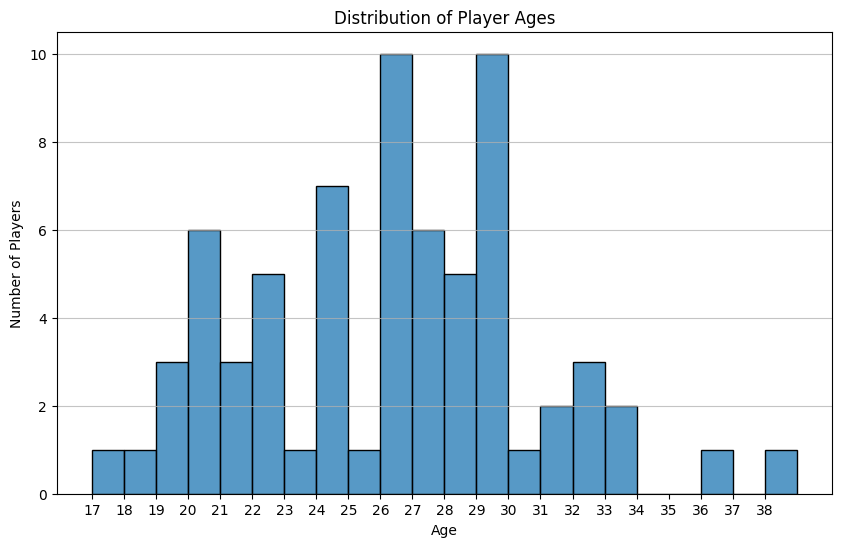

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), bins=range(min(df['Age'].dropna().astype(int)), max(df['Age'].dropna().astype(int)) + 2), kde=False)
plt.title('Distribution of Player Ages')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.xticks(range(min(df['Age'].dropna().astype(int)), max(df['Age'].dropna().astype(int)) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

### Selected Mixed among Preferences

In [ ]:
# @title
df_cogT1_mixed = df_cog_tryout1[df_cog_tryout1['Please rank your preferences for the teams you are trying out for.  [Mixed ]']
                                .notna()][['Name_clean', 'Email Address', 'Please rank your preferences for the teams you are trying out for.  [Mixed ]']]
df_cogT1_mixed

Loading ITables v2.7.3 from the internet... (need help?)


## First choice Sixers second choice Mixed or Other

In [ ]:
# @title
df_filtered = df[
    (df['Please rank your preferences for the teams you are trying out for.  [6ixers]'] == '1st choice') &
    (
        (df['Please rank your preferences for the teams you are trying out for.  [Other]'] == '2nd choice') |
        (df['Please rank your preferences for the teams you are trying out for.  [Mixed ]'] == '2nd choice')
    )
]

display(df_filtered[['Name_clean',
                     'Email Address', 'Please rank your preferences for the teams you are trying out for.  [Other]',
                     'Please rank your preferences for the teams you are trying out for.  [Mixed ]',
                     'Please rank your preferences for the teams you are trying out for.  [Incognito]'
                     ]])

Loading ITables v2.7.3 from the internet... (need help?)


# Evaluation Form Setup

In [ ]:
unique_names_cog_tryout1 = df_cog_tryout1['Name_clean'].unique()
df_eval_cog_tryout1 = pd.DataFrame(unique_names_cog_tryout1, columns=['Name_clean'])
df_eval_cog_tryout1['O with Disc'] = pd.NA
df_eval_cog_tryout1['D with Disc'] = pd.NA
df_eval_cog_tryout1['O without Disc'] = pd.NA
df_eval_cog_tryout1['D without Disc'] = pd.NA
df_eval_cog_tryout1['Creativity'] = pd.NA
df_eval_cog_tryout1['Resilience'] = pd.NA
df_eval_cog_tryout1['Comments'] = pd.NA



In [ ]:
# Export to CSV
df_eval_cog_tryout1.to_csv('df_eval_cog_tryout1.csv', index=False)